# Analysis — Air Quality & Low Emission Zone (LEZ) Paris

## Objective
Analyse the impact of the Paris LEZ (Crit'Air 3 ban, June 2021) on NO₂ concentrations.
Key question: did the LEZ introduction lead to a measurable reduction in NO₂,
and does this effect differ by neighbourhood income level?

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display, HTML

sys.path.insert(0, str(Path().resolve().parent))
from src.data_loader import (
    load_stations_metadata,
    load_zfe_perimeter,
    load_processed_airparif,
    load_processed_meteo,
    load_processed_insee,
    load_iris_contours,
)

# LEZ restriction date
ZFE_DATE = "2021-06-01"

print("Environment ready")


Environment ready


## 1. Spatial classification of stations

Station coordinates retrieved via OpenStreetMap Nominatim geocoding API.
Source queries documented in the `geocoding_query` column.

In [2]:
# Load station coordinates
stations_gdf = load_stations_metadata()

# Load ZFE perimeter
zfe = load_zfe_perimeter()

# Spatial join: classify each station as inside or outside ZFE
stations_gdf["inside_zfe"] = stations_gdf.within(zfe.union_all())

display(stations_gdf[["station_code", "inside_zfe"]])
print(f"Inside ZFE: {stations_gdf['inside_zfe'].sum()}")
print(f"Outside ZFE: {(~stations_gdf['inside_zfe']).sum()}")


,station_code,inside_zfe
0,OPERA,True
1,RN20,False
2,BP_EST,True
3,ARG,False
4,AUB,False
5,AUT,True
6,A1,False
7,BOB,False
8,BONAP,True
9,CELES,True


Inside ZFE: 13
Outside ZFE: 23


**Observations on Spatial classification:**
- 13 stations inside the LEZ, 23 outside
- Périphérique stations (BP_EST, AUT) classified as inside — consistent with the ZFE perimeter boundary
- Outside stations serve as the control group for the diff-in-diff analysis

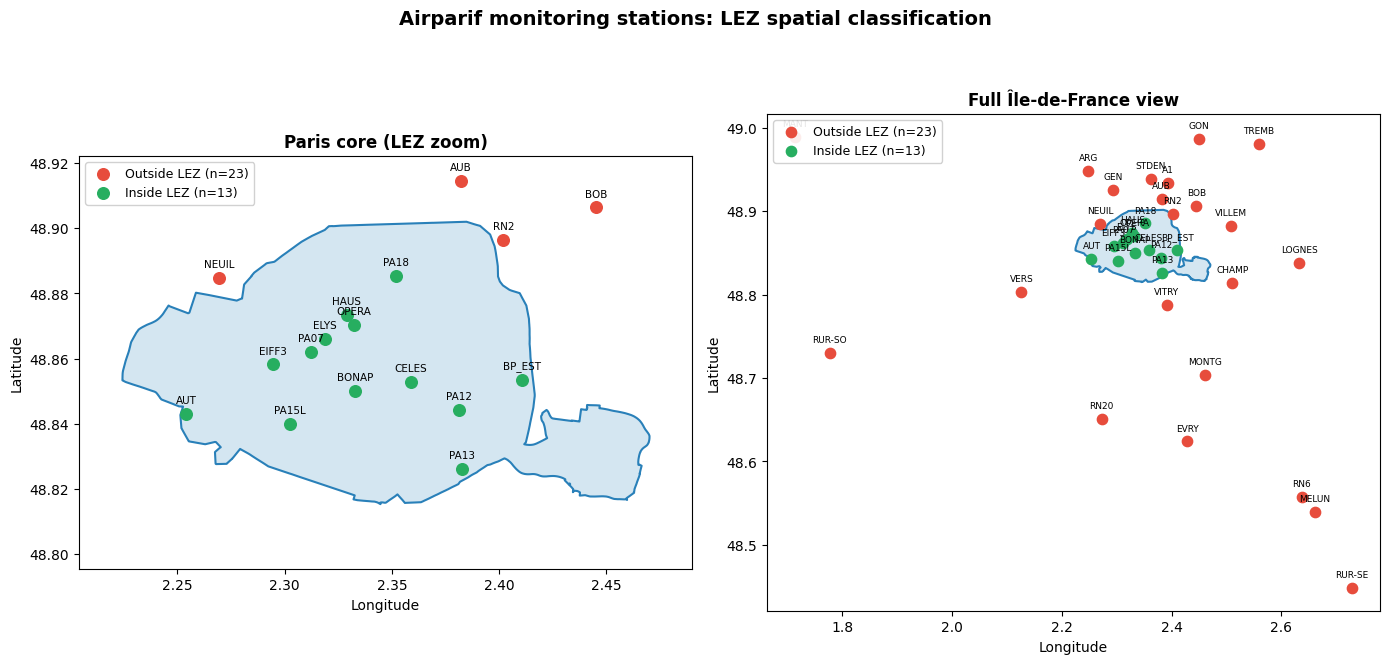

In [3]:
from pathlib import Path
Path("../outputs").mkdir(exist_ok=True)

outside_s = stations_gdf[~stations_gdf["inside_zfe"]]
inside_s = stations_gdf[stations_gdf["inside_zfe"]]

# Paris zoom uses the ZFE polygon's bounding box as a reference frame
xmin, ymin, xmax, ymax = zfe.total_bounds
margin = 0.02
paris_xlim = (xmin - margin, xmax + margin)
paris_ylim = (ymin - margin, ymax + margin)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- LEFT: Paris zoom ---
ax = axes[0]
zfe.plot(ax=ax, color="#d4e6f1", edgecolor="#2980b9", linewidth=1.5, zorder=1)
outside_s.plot(ax=ax, color="#e74c3c", markersize=70, marker="o", label="Outside LEZ (n=23)", zorder=3)
inside_s.plot(ax=ax, color="#27ae60", markersize=70, marker="o", label="Inside LEZ (n=13)", zorder=3)

for _, row in stations_gdf.iterrows():
    if paris_xlim[0] <= row.geometry.x <= paris_xlim[1] and paris_ylim[0] <= row.geometry.y <= paris_ylim[1]:
        ax.annotate(
            row["station_code"],
            xy=(row.geometry.x, row.geometry.y),
            fontsize=7.5, ha="center", va="bottom",
            xytext=(0, 6), textcoords="offset points", zorder=4
        )

ax.set_xlim(paris_xlim)
ax.set_ylim(paris_ylim)
ax.set_title("Paris core (LEZ zoom)", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# --- RIGHT: Full Île-de-France view ---
ax = axes[1]
zfe.plot(ax=ax, color="#d4e6f1", edgecolor="#2980b9", linewidth=1.5, zorder=1)
outside_s.plot(ax=ax, color="#e74c3c", markersize=55, marker="o", label="Outside LEZ (n=23)", zorder=3)
inside_s.plot(ax=ax, color="#27ae60", markersize=55, marker="o", label="Inside LEZ (n=13)", zorder=3)

for _, row in stations_gdf.iterrows():
    ax.annotate(
        row["station_code"],
        xy=(row.geometry.x, row.geometry.y),
        fontsize=6.5, ha="center", va="bottom",
        xytext=(0, 6), textcoords="offset points", zorder=4
    )

ax.set_title("Full Île-de-France view", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.suptitle("Airparif monitoring stations: LEZ spatial classification",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/map_stations_zfe.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Temporal analysis

In [4]:
# Load cleaned datasets
airparif = load_processed_airparif()
meteo = load_processed_meteo()

# Split into before/after ZFE
before = airparif[airparif.index < ZFE_DATE]
after = airparif[airparif.index >= ZFE_DATE]

print(f"Before ZFE: {before.index.min().date()} to {before.index.max().date()} ({len(before)} records)")
print(f"After ZFE:  {after.index.min().date()} to {after.index.max().date()} ({len(after)} records)")

Before ZFE: 2019-01-01 to 2021-05-31 (21167 records)
After ZFE:  2021-06-01 to 2024-01-01 (22657 records)


In [5]:
# Separate inside/outside stations
inside_stations = stations_gdf[stations_gdf["inside_zfe"]]["station_code"].tolist()
outside_stations = stations_gdf[~stations_gdf["inside_zfe"]]["station_code"].tolist()

# Mean NO2 before and after ZFE by group
results = pd.DataFrame({
    "inside_before": before[inside_stations].mean(),
    "inside_after": after[inside_stations].mean(),
    "outside_before": before[outside_stations].mean(),
    "outside_after": after[outside_stations].mean(),
})

summary = pd.DataFrame({
    "group": ["Inside LEZ", "Outside LEZ"],
    "mean_NO2_before": [
        before[inside_stations].mean().mean(),
        before[outside_stations].mean().mean()
    ],
    "mean_NO2_after": [
        after[inside_stations].mean().mean(),
        after[outside_stations].mean().mean()
    ],
})
summary["change"] = summary["mean_NO2_after"] - summary["mean_NO2_before"]
summary["change_pct"] = (summary["change"] / summary["mean_NO2_before"] * 100).round(1)

display(summary.round(2).set_index("group"))


,mean_NO2_before,mean_NO2_after,change,change_pct
group,,,,
Inside LEZ,35.92,32.02,-3.90,-10.9
Outside LEZ,26.22,22.87,-3.34,-12.8


**Observations on Temporal analysis:**
- NO₂ decreases in both groups after June 2021
- Inside LEZ: -3.90 µg/m³ (-10.9%)
- Outside LEZ: -3.34 µg/m³ (-12.8%)
- The larger % reduction outside the LEZ suggests a general downward trend not specific to the ZFE
- Raw comparison is insufficient — weather control and diff-in-diff analysis required

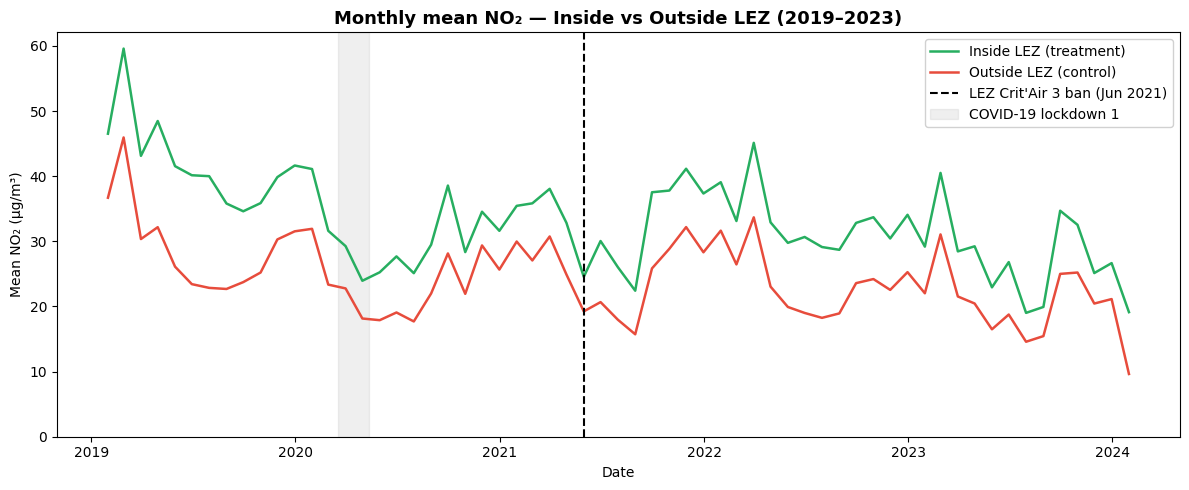

In [6]:
# Monthly mean NO2 per group
airparif_monthly = airparif.resample("ME").mean()
inside_monthly = airparif_monthly[inside_stations].mean(axis=1)
outside_monthly = airparif_monthly[outside_stations].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(inside_monthly.index, inside_monthly, color="#27ae60", linewidth=1.8, label="Inside LEZ (treatment)")
ax.plot(outside_monthly.index, outside_monthly, color="#e74c3c", linewidth=1.8, label="Outside LEZ (control)")

ax.axvline(pd.Timestamp(ZFE_DATE), color="black", linestyle="--", linewidth=1.5, label="LEZ Crit'Air 3 ban (Jun 2021)")

# COVID-19 first lockdown context (France: 17 Mar – 11 May 2020)
ax.axvspan(pd.Timestamp("2020-03-17"), pd.Timestamp("2020-05-11"), alpha=0.12, color="gray", label="COVID-19 lockdown 1")

ax.set_ylim(bottom=0)
ax.set_xlabel("Date")
ax.set_ylabel("Mean NO₂ (µg/m³)")
ax.set_title("Monthly mean NO₂ — Inside vs Outside LEZ (2019–2023)", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("../outputs/timeseries_no2_zfe.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Difference-in-differences analysis

The diff-in-diff method estimates the causal effect of the LEZ by comparing
the evolution of NO₂ in stations **inside** the LEZ (treatment group) versus
stations **outside** the LEZ (control group), before and after June 2021.

Weather variables (wind speed, precipitation, temperature) are included as controls
to isolate the LEZ effect from meteorological variation.

In [7]:
meteo = load_processed_meteo()

# Build panel dataset: one row per station per hour
airparif_long = airparif.stack().reset_index()
airparif_long.columns = ["datetime", "station_code", "no2"]

# Remove timezone info to align with meteo index
airparif_long["datetime"] = airparif_long["datetime"].dt.tz_localize(None)

# Add treatment variable (inside LEZ)
airparif_long = airparif_long.merge(
    stations_gdf[["station_code", "inside_zfe"]], on="station_code"
)

# Add post-ZFE variable
airparif_long["post"] = (airparif_long["datetime"] >= ZFE_DATE).astype(int)
airparif_long["treated"] = airparif_long["inside_zfe"].astype(int)
airparif_long["did"] = airparif_long["post"] * airparif_long["treated"]

# Add weather controls
airparif_long = airparif_long.merge(meteo, left_on="datetime", right_index=True, how="left")

# Drop NaN rows
airparif_long = airparif_long.dropna(subset=["no2", "windspeed_10m", "precipitation", "temperature_2m"])

print(f"Panel dataset: {airparif_long.shape}")
display(airparif_long.head())


Panel dataset: (1518446, 10)


,datetime,station_code,no2,inside_zfe,post,treated,did,windspeed_10m,precipitation,temperature_2m
0,2019-01-01 01:00:00,OPERA,81.5,True,0,1,0,6.2,0.0,6.6
1,2019-01-01 01:00:00,RN20,53.3,False,0,0,0,6.2,0.0,6.6
2,2019-01-01 01:00:00,BP_EST,26.3,True,0,1,0,6.2,0.0,6.6
3,2019-01-01 01:00:00,ARG,18.6,False,0,0,0,6.2,0.0,6.6
4,2019-01-01 01:00:00,AUB,20.7,False,0,0,0,6.2,0.0,6.6


In [8]:
# Diff-in-diff regression with weather controls and HAC-robust standard errors
# no2 = alpha + beta1*treated + beta2*post + beta3*did + weather controls + error
# beta3 (did coefficient) = the LEZ causal effect estimate
# HAC (maxlags=24): corrects standard errors for autocorrelation in hourly time series
model = smf.ols(
    "no2 ~ treated + post + did + windspeed_10m + precipitation + temperature_2m",
    data=airparif_long
).fit(cov_type='HAC', cov_kwds={'maxlags': 24})

display(HTML(model.summary().as_html()))


**Results from the DiD model (HAC-robust standard errors):**
- **DID coefficient: -1.22 µg/m³ (p < 0.001)** — the LEZ Crit'Air 3 ban is associated with an additional NO₂ reduction of 1.22 µg/m³ inside the zone, after controlling for weather
- General downward trend (post): -3.49 µg/m³ across all stations — the LEZ explains only part of the overall reduction
- Weather controls perform as expected: wind (-0.92), rain (-0.45), temperature (-0.49) all reduce NO₂
- R² = 0.15 — low but expected without station fixed effects
- HAC standard errors (maxlags=24) applied — note that `precipitation` std err increases from 0.045 to 0.107, reflecting high autocorrelation in weather data; the DID coefficient remains highly significant

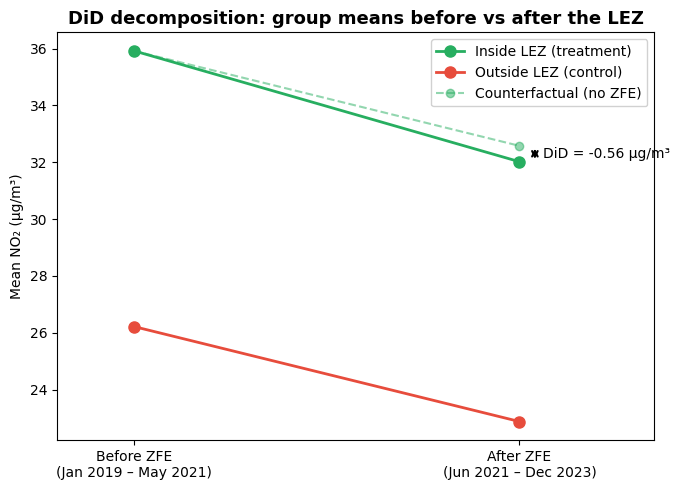

In [9]:
# DiD decomposition: the 4 group means that underpin the estimate
before_in  = before[inside_stations].mean().mean()
after_in   = after[inside_stations].mean().mean()
before_out = before[outside_stations].mean().mean()
after_out  = after[outside_stations].mean().mean()

# Counterfactual: what inside would look like if it followed the same trend as outside
counterfactual = before_in + (after_out - before_out)
did_estimate = after_in - counterfactual  # should match DiD coefficient direction

fig, ax = plt.subplots(figsize=(7, 5))
x = [0, 1]

ax.plot(x, [before_in, after_in],           "o-", color="#27ae60", linewidth=2, markersize=8, label="Inside LEZ (treatment)")
ax.plot(x, [before_out, after_out],         "o-", color="#e74c3c", linewidth=2, markersize=8, label="Outside LEZ (control)")
ax.plot(x, [before_in, counterfactual],     "o--", color="#27ae60", linewidth=1.5, markersize=6, alpha=0.5, label="Counterfactual (no ZFE)")

# Bracket showing the DiD gap
ax.annotate(
    "", xy=(1.04, after_in), xytext=(1.04, counterfactual),
    arrowprops=dict(arrowstyle="<->", color="black", lw=1.5)
)
ax.text(1.06, (after_in + counterfactual) / 2, f"DiD = {did_estimate:+.2f} µg/m³",
        va="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(["Before ZFE\n(Jan 2019 – May 2021)", "After ZFE\n(Jun 2021 – Dec 2023)"])
ax.set_ylabel("Mean NO₂ (µg/m³)")
ax.set_title("DiD decomposition: group means before vs after the LEZ", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(-0.2, 1.35)
plt.tight_layout()
plt.savefig("../outputs/did_parallel_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Analysis by income level

Each Airparif station is matched to its nearest IRIS zone via spatial join.
The median income of that IRIS (`DISP_MED21`) is then used as a continuous variable
to test whether the LEZ effect varies with neighbourhood income level.

In [10]:
# Load IRIS contours and income data
iris_contours = load_iris_contours()
insee = load_processed_insee()

# Merge contours with income data
iris_income = iris_contours.merge(insee, left_on="CODE_IRIS", right_on="IRIS", how="left")

print(f"IRIS contours: {len(iris_contours)} zones")
print(f"After merge: {iris_income['DISP_MED21'].notna().sum()} zones with income data")
display(iris_income[["CODE_IRIS", "DISP_MED21"]].head())


IRIS contours: 2752 zones
After merge: 2529 zones with income data


,CODE_IRIS,DISP_MED21
0,930630101,NaN
1,940480101,NaN
2,930730101,21570.0
3,940340101,19820.0
4,940210101,NaN


In [11]:
# Keep only IRIS zones that have income data
iris_with_income = iris_income[iris_income["DISP_MED21"].notna()].copy()

# Reproject to Lambert 93 (EPSG:2154) for accurate distance calculation
iris_proj = iris_with_income.to_crs("EPSG:2154")
stations_proj = stations_gdf.to_crs("EPSG:2154")

# Spatial join: nearest IRIS with income data for every station
stations_iris = gpd.sjoin_nearest(
    stations_proj,
    iris_proj[["CODE_IRIS", "DISP_MED21", "geometry"]],
    how="left"
).to_crs("EPSG:4326")

display(stations_iris[["station_code", "inside_zfe", "DISP_MED21"]])


,station_code,inside_zfe,DISP_MED21
0,OPERA,True,39500.0
1,RN20,False,26530.0
2,BP_EST,True,15350.0
3,ARG,False,22160.0
4,AUB,False,16650.0
5,AUT,True,24530.0
6,A1,False,15070.0
7,BOB,False,15070.0
8,BONAP,True,43450.0
9,CELES,True,24750.0


### Interaction model: LEZ effect × median income

Median income is included as a continuous variable interacted with the diff-in-diff term.
The interaction coefficient `did:income_std` measures whether the LEZ effect
varies with neighbourhood income — a negative value would indicate that
wealthier areas benefit less from the restriction.
Income is standardised (z-score) so the coefficient is expressed per standard deviation.

In [12]:
# Map median income to panel dataset
income_map_cont = stations_iris.set_index("station_code")["DISP_MED21"]
airparif_long["median_income"] = airparif_long["station_code"].map(income_map_cont)

# Standardise income for interpretability (z-score)
# Coefficient will represent effect per standard deviation of income
income_mean = airparif_long["median_income"].mean()
income_std = airparif_long["median_income"].std()
airparif_long["income_std"] = (airparif_long["median_income"] - income_mean) / income_std

# Drop rows with missing income
airparif_ols = airparif_long.dropna(subset=["income_std", "no2", "windspeed_10m"])

print(f"Observations: {len(airparif_ols):,}")
print(f"Income mean: {income_mean:,.0f} €/year, std: {income_std:,.0f} €/year")

Observations: 1,518,446
Income mean: 27,955 €/year, std: 11,655 €/year


In [13]:
# Diff-in-diff with continuous income interaction and HAC-robust standard errors
# did:income_std = does the LEZ effect vary with neighbourhood income?
model_income = smf.ols(
    "no2 ~ treated + post + did + income_std + did:income_std"
    " + windspeed_10m + precipitation + temperature_2m",
    data=airparif_ols
).fit(cov_type='HAC', cov_kwds={'maxlags': 24})

display(HTML(model_income.summary().as_html()))


**Results from the LEZ × income interaction model (HAC-robust standard errors):**
- `did:income_std` coefficient: +0.049 (p = 0.121) — **not statistically significant**
- Conclusion: the LEZ effect does not significantly vary with neighbourhood income level
- The restriction reduced NO₂ similarly across all income groups
- This contradicts equity concerns that ZFE policies disproportionately benefit wealthier areas
- `income_std`: -5.02 µg/m³ — wealthier neighbourhoods have structurally lower NO₂ baseline
- R² improved from 0.150 to 0.192 by including income as a control variable
- **Limitation:** only 36 stations — low statistical power to detect income interaction effects

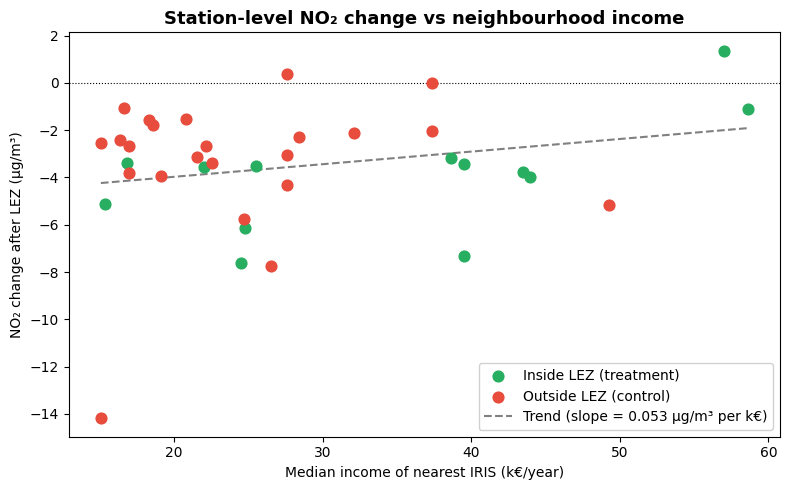

In [14]:
# Per-station NO2 change: mean after ZFE minus mean before ZFE
station_change = pd.DataFrame({
    "before": before.mean(),
    "after": after.mean(),
})
station_change["change"] = station_change["after"] - station_change["before"]
station_change.index.name = "station_code"
station_change = station_change.reset_index()

# Merge with income and group classification
station_plot = station_change.merge(
    stations_iris[["station_code", "DISP_MED21", "inside_zfe"]], on="station_code"
)

inside_p = station_plot[station_plot["inside_zfe"]]
outside_p = station_plot[~station_plot["inside_zfe"]]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(inside_p["DISP_MED21"] / 1000, inside_p["change"],  color="#27ae60", s=60, zorder=3, label="Inside LEZ (treatment)")
ax.scatter(outside_p["DISP_MED21"] / 1000, outside_p["change"], color="#e74c3c", s=60, zorder=3, label="Outside LEZ (control)")

# Overall trend line
x_vals = station_plot["DISP_MED21"] / 1000
y_vals = station_plot["change"]
m, b = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="gray", linewidth=1.5, label=f"Trend (slope = {m:.3f} µg/m³ per k€)")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Median income of nearest IRIS (k€/year)")
ax.set_ylabel("NO₂ change after LEZ (µg/m³)")
ax.set_title("Station-level NO₂ change vs neighbourhood income", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("../outputs/income_vs_no2_change.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Limitations

**1. Low number of monitoring stations (n=36)**
With only 36 stations, statistical power to detect interaction effects is limited.
A genuine income-modulated LEZ effect may exist but remain undetectable at this sample size.

**2. Single weather measurement point**
Weather controls use a single Paris-centre data point (Open-Meteo) for all stations.
Meteorological conditions in outer stations (Mantes-la-Jolie, Melun, Versailles)
may differ substantially, leaving residual confounding.

**3. No station fixed effects**
Each station has permanent characteristics (distance to road, traffic type, surrounding built environment)
that are not controlled for. These may bias the estimated coefficients.

**4. IRIS income as a proxy for driver income**
The median income of the IRIS surrounding a station does not necessarily reflect
the socio-economic profile of drivers circulating on nearby roads —
particularly for roadside and périphérique stations.

**5. Station geocoding approximation**
Station coordinates were retrieved via OpenStreetMap Nominatim geocoding
based on station names and addresses. Coordinate precision may affect
the spatial join with IRIS zones and the LEZ perimeter classification.

**6. COVID-19 confounding in the pre-treatment baseline**
The pre-ZFE period (2019–2021) includes the French lockdowns of 2020
(March–May, October–December) and early 2021 (April–May), during which
traffic fell by 50–80%. This depresses the pre-ZFE NO₂ baseline,
potentially underestimating the true LEZ effect. Lockdown periods are
visible in the time series but are not explicitly excluded from the model.